## Exercise Project 1 

Dataset: [NYC Housing Prices](https://www.kaggle.com/datasets/ishank2005/nyc-housing-prices-csv)

Shape: `34k rows, 19 columns`

Target Variable: `sale_price`

Method: `Linear Regression`

Extra Tools: `Mlflow`

Column Descriptions (Complete):

| Column        | Description |
|--------------|-------------|
| borough_x    | *Borough code associated with the property sale record, sourced from the NYC Citywide Rolling Sales dataset.* |
| block        | *NYC tax block identifier for the property, used as part of the Borough–Block–Lot (BBL) system.* |
| lot          | *NYC tax lot identifier for the property, used as part of the Borough–Block–Lot (BBL) system.* |
| sale_price   | *Recorded sale price of the property transaction in US dollars. Non-arm’s-length and invalid transactions have been removed.* |
| zip_code     | *ZIP code of the property as recorded in the sales transaction data.* |
| borough_y    | *Borough code associated with the property tax lot, sourced from the PLUTO building dataset.* |
| yearbuilt    | *Year in which the primary structure on the tax lot was originally constructed.* |
| lotarea      | *Total land area of the tax lot, measured in square feet.* |
| bldgarea     | *Total gross building floor area on the tax lot, measured in square feet.* |
| resarea      | *Portion of the building floor area used for residential purposes, measured in square feet.* |
| comarea      | *Total commercial floor area within the building, measured in square feet.* |
| unitsres     | *Number of residential housing units on the tax lot.* |
| unitstotal   | *Total number of units on the tax lot, including residential and non-residential units.* |
| numfloors    | *Number of floors in the primary building on the tax lot.* |
| latitude     | *Latitude coordinate of the property location, expressed in decimal degrees.* |
| longitude    | *Longitude coordinate of the property location, expressed in decimal degrees.* |
| landuse      | *Numeric land use category code describing the primary use of the property (e.g., residential, commercial, mixed-use).* |
| bldgclass    | *NYC building class code indicating the structural and usage classification of the property.* |
| building_age | *Age of the building in years at the time of sale, calculated as sale year minus year built.* |






---

### Code

In [22]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from skfeature.function.similarity_based import fisher_score
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn.preprocessing import OneHotEncoder
import mlflow
import mlflow.sklearn

# Reading the dataframe and storing it.
df = pd.read_csv("datasets/nyc_housing.csv")
df.head(5)

,borough_x,block,lot,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
0,1,400,11,280000,10009.0,MN,1900.0,2404.0,6875.0,6875.0,0.0,18.0,18.0,5.0,40.724415,-73.983891,2.0,C6,125.0
1,1,402,36,2000000,10009.0,MN,1900.0,1919.0,7810.0,6810.0,1000.0,8.0,10.0,5.0,40.724975,-73.981535,2.0,C4,125.0
2,1,402,60,3400000,10009.0,MN,1920.0,2150.0,6152.0,5352.0,800.0,8.0,9.0,5.0,40.725346,-73.983112,4.0,C7,105.0
3,1,404,42,4000000,10009.0,MN,1855.0,2369.0,6990.0,6990.0,0.0,10.0,10.0,5.0,40.727398,-73.980600,2.0,C4,170.0
4,1,372,55,655000,10009.0,MN,1920.0,5298.0,17990.0,17990.0,0.0,20.0,20.0,5.0,40.720621,-73.979534,2.0,C6,105.0


## Cleaning

|Step|Description|
|---|---|
|1| <bold style="background:yellow;color:black;">Data Cleaning </bold>|
|2| Feature Engineering|
|3| ML Implementation|
|4| Model Application|


#### Checking Shape

In [23]:
# Checking the amount of columns and rows.
df.shape

# That seems like a reasonable amount of data. Lots to work with.

(34439, 19)

#### Missing Values

In [24]:
# Checking for missing values
df.isna().sum()

# A small amount of rows have missing values. 
# Getting rid of all the NaN will be trivial 200/34000 = .5% of the data. Not timeseries.

# Dropping nan values.
df = df.dropna()

##### Dropping Columns

In [25]:
# Filtering out any rows which may be for commercial uses.
df[df['comarea'] > 0].shape

# Dropping co-dependent columns
df = df.drop(["borough_x",       # Related to borough_y
                'latitude',      # Probably just noise in the data.
                'longitude',     # Probably just noise in the data.
                'yearbuilt',     # This is co-dependent with `buildingage`
                'comarea',       # In this dataset: bldgarea = comarea + resarea. co-dependent.
                'resarea',       # In this dataset: bldgarea = comarea + resarea. co-dependent.
                'lot',           # We have borough_y. This is too specific, you'd have distributions of 1 unit being in lot ABC, hardly statistical.
                'block',         # We have borough_y, too specific. We cant have 3 units in a block be a statistical weight for an ML model.
                'zip_code',      # Too specific, it'll affect distribution.
                'landuse',       # This is often co-dependent with bldgclass (D4 bldgclass = landuse 3 for example).      
], axis=1)

df.head(3)


,sale_price,borough_y,lotarea,bldgarea,unitsres,unitstotal,numfloors,bldgclass,building_age
0,280000,MN,2404.0,6875.0,18.0,18.0,5.0,C6,125.0
1,2000000,MN,1919.0,7810.0,8.0,10.0,5.0,C4,125.0
2,3400000,MN,2150.0,6152.0,8.0,9.0,5.0,C7,105.0


In [26]:
# # This is a categorical variable. 
# # 7, 10 , and 9 don't really have a lot of data. Let's drop them
# df['landuse'].value_counts()

# # Filtering out 7, 10 ,9
# df = df[
#     (df["landuse"] != 7) &
#     (df['landuse'] != 10) &
#     (df['landuse'] != 9)
# ]


In [27]:
# There's rare category values here as well
value_counts = df['bldgclass'].value_counts().head(30)

# Keep only values that occur at least min_count times
df = df[df['bldgclass'].isin(value_counts[value_counts >= 30].index)]


In [28]:
df['borough_y'].value_counts()

borough_y
QN    12704
BK     9387
SI     3797
MN     3761
BX     3211
Name: count, dtype: int64

In [29]:
# # This boxplot shows that there's a ton of outliers in landuse 3. Let's get rid of those.
# filter = df[df['landuse'] == 3 ]
# sns.boxplot(filter, x='sale_price')

##### Turning Categorical Columns into Numbers

In [30]:
# List of columns to convert to numbers.
categorical_columns = ["borough_y",  # Example values: MN, ME, BK
                       "bldgclass", # Example values: C6, K4, C8
                    #    "landuse",   # They are numbers, but 1 = residential, 2 = commercial.
                       ]


# Converts columns into binary, separate columns.
for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)


---



### Selecting Features

|Step|Description|
|---|---|
|1| Data Cleaning|
|2| <bold style="background:yellow;color:black;">Feature Engineering</bold>|
|3| ML Implementation|
|4| Model Application|

####  Target Outlier & Skew Elimination


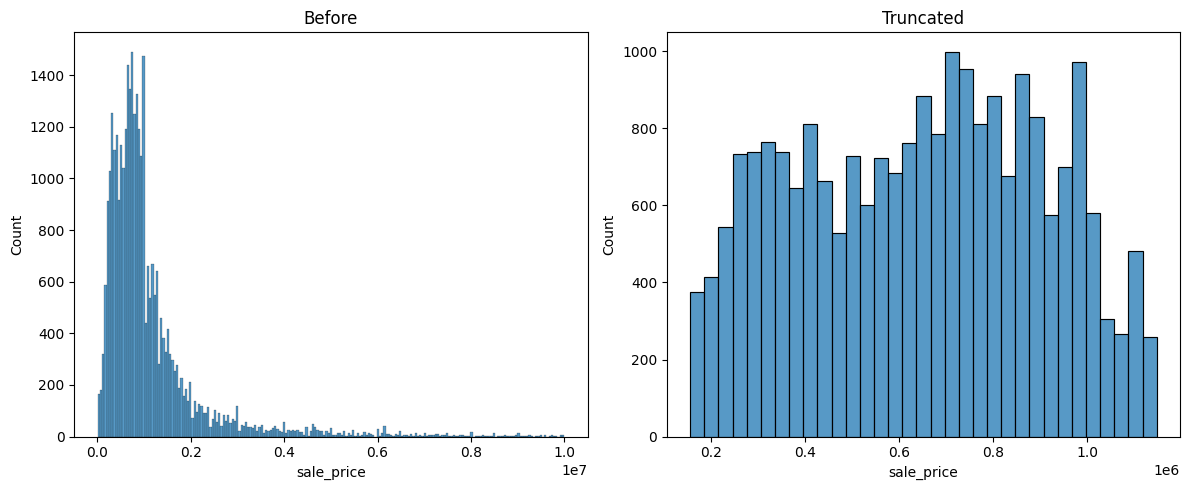

Rows left: 22351


In [31]:
# Target variable cutoffs.
y_trunc_floor = 0.02
y_trunc_ceiling = 0.70

# Creates three canvases for histplots to show my work.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# HISTPLOT 0
sns.histplot(df, x='sale_price', ax=axes[0])

# Truncating the Y variable.
df = df[
    (df['sale_price'] >= df['sale_price'].quantile(q=y_trunc_floor)) &
    (df['sale_price'] <= df['sale_price'].quantile(q=y_trunc_ceiling))
    ]

# HISTPLOT 1, truncated
sns.histplot(df, x='sale_price', ax=axes[1])

# Histplot titles
axes[0].set_title("Before")
axes[1].set_title("Truncated")
plt.tight_layout()
plt.show()


# RESULTS:
# Not great. But it's probably the best we can get.
# We'll have to wait until Tuomas can give some pointers.

# SANITY CHECK:
# Let's check how many rows we have left.
print(f"Rows left: {df.shape[0]}")

In [32]:
df

,sale_price,lotarea,bldgarea,unitsres,unitstotal,numfloors,building_age,borough_y_BK,borough_y_BX,borough_y_MN,...,bldgclass_D4,bldgclass_E1,bldgclass_K1,bldgclass_K2,bldgclass_K4,bldgclass_O2,bldgclass_S1,bldgclass_S2,bldgclass_S3,bldgclass_S9
0,280000,2404.0,6875.0,18.0,18.0,5.0,125.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,655000,5298.0,17990.0,20.0,20.0,5.0,105.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5,470000,3132.0,2440.0,1.0,2.0,2.0,81.0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
6,474000,3132.0,2440.0,1.0,2.0,2.0,81.0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
7,1050000,1400.0,2700.0,3.0,3.0,3.0,126.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34432,890000,5220.0,2700.0,2.0,2.0,3.0,29.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
34433,765000,3302.0,1440.0,2.0,2.0,2.0,29.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
34434,850000,3180.0,1300.0,2.0,2.0,2.0,29.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
34435,855000,3700.0,2500.0,2.0,2.0,3.0,30.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Pearson Correlation Matrix

<Axes: >

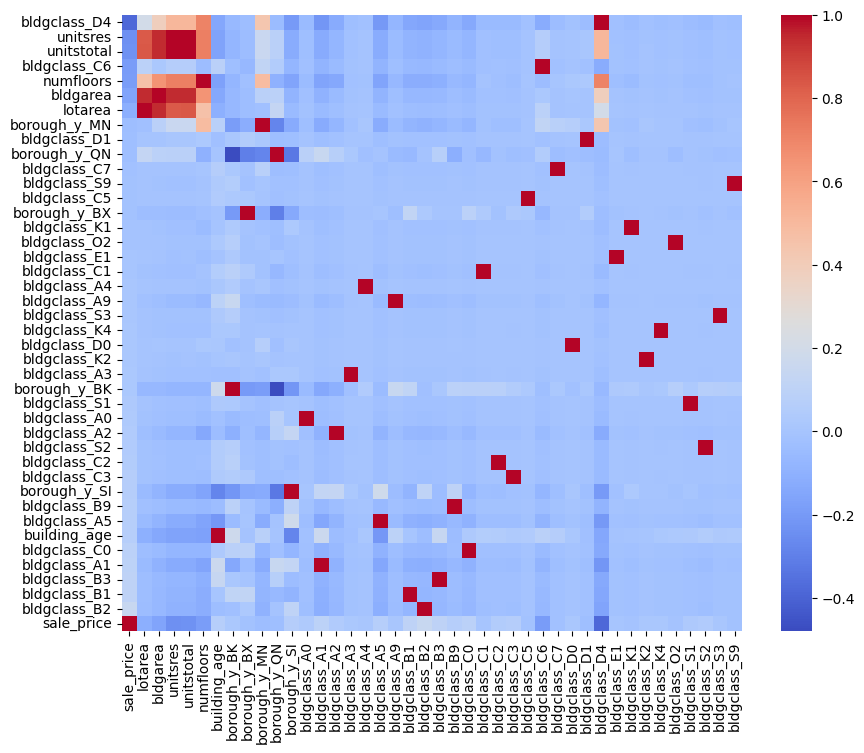

In [33]:
# Pearson correlation heatmap (matrix)
correlations = df.corr( method='pearson',numeric_only=True).sort_values(by='sale_price')
plt.figure(figsize=(10,8))
sns.heatmap(correlations, cmap='coolwarm')

# df = df[['sale_price', 'resarea', 'bldgarea','unitsres','unitstotal','numfloors', 'landuse','borough_y','bldgclass']]


#### 

#### Changing Categorical Columns to Numbers

In [34]:
# Get all of the features with a high correlation value.
best_features = df.corr(numeric_only=True)['sale_price'].reset_index()

# Get the absolute value of the corr.
best_features['sale_price'] = abs(best_features['sale_price'])

# Retrieving the best possible features via the absolute values of their
# correlation values. 
best_features = best_features.sort_values("sale_price", ascending=False)
best_features = best_features[best_features["sale_price"] < 0.9]
best_features

,index,sale_price
32,bldgclass_D4,0.385671
3,unitsres,0.238034
4,unitstotal,0.236748
28,bldgclass_C6,0.194586
5,numfloors,0.185352
2,bldgarea,0.156987
20,bldgclass_B2,0.148190
1,lotarea,0.115214
19,bldgclass_B1,0.102747
21,bldgclass_B3,0.101855


In [35]:
# And now we put this into a list. This will be the features we'll use
list_features = list(best_features['index'])
len(list_features)


41

#### FULL Correlation Matrix (With categorical columns)

---

### ML Implementation

|Step|Description|
|---|---|
|1| Data Cleaning|
|2| Feature Engineering|
|3| <bold style="background:yellow;color:black;">ML Implementation</bold>|
|4| Model Application|


#### Linear Regression Model Creation

In [37]:
# Constants
XY_SPLIT = 0.3

# Defining dependent, independent variables.
X = df[list_features]
y = df['sale_price']

# train/test-split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=XY_SPLIT, random_state=101)

# Initializes the experiment in MLFLOW.
mlflow.set_experiment("ex1_project_a")

with mlflow.start_run():
    # Initalization
    lm = LinearRegression()
    lm.fit(X_train, y_train)

    # Find the intercept value of the regression
    intercept = lm.intercept_

    # Create a list of coefficients for each feature.
    coefs = lm.coef_
    print(coefs)

    # Predict the data with the model.
    predictions = lm.predict(X_test)


    # -- METRICS RECORDING -- 
    mae = metrics.mean_absolute_error(y_test, predictions)
    mse = metrics.mean_squared_error(y_test, predictions)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
    r_sq = metrics.r2_score(y_test, predictions)

    # -- MLFLOW LOGGING --
    mlflow.set_tag("dataset", "kaggle_house_prices_v1")
    mlflow.set_tag("data_split", str(XY_SPLIT))
    mlflow.log_param("exercise_project_name","ex1_a")
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("y_variable_truncation_amt", f"{y_trunc_floor, y_trunc_ceiling}")
    mlflow.log_param("features", str(X.columns))
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r_squared", r_sq)
    mlflow.sklearn.log_model(lm, "model")



2026/01/21 23:49:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[-3.06220429e+05  7.21338080e+02 -1.09804289e+03 -2.40174581e+05
  7.95719881e+03  3.20861409e-01  1.24284743e+05 -1.39235418e-01
  9.15565793e+04  9.91197969e+04  5.75447137e+04  7.88347420e+04
 -5.98939176e+01  3.65953067e+04  1.01081858e+05 -5.58639156e+04
  1.37894425e+05  1.02853584e+05  9.08150141e+04  5.44907216e+04
  9.35378262e+04  1.48418647e+05 -1.83571011e+05  1.38862718e+05
 -2.14943664e+04 -1.86879783e+04 -1.69631379e+05  4.95242912e+04
 -1.16039256e+05  6.25095800e+04 -1.31465719e+05 -5.23723867e+04
 -7.53103635e+04  2.93922445e+04 -5.87119193e+04  2.41462111e+04
 -1.84069272e+03 -1.13877758e+04 -5.65503580e+04 -1.01755038e+04
 -1.19653678e+04]


#### Metrics & Parameters

In [38]:
# -- PRINT METRICS --
print("METRICS")
print("--------------------------")
print("MAE")
print(f"{round(mae,2)} \n")
print("MSE")
print(f"{round(mse,2)} \n")
print("RMSE")
print(f"{round(rmse,2)} \n")
print('R-squared:')
print(f"{round(r_sq,2)} \n")

# -- PRINT PARAMETERS
print("PARAMETERS")
print("--------------------------")
print("Target Variable Truncation Amount:")
print(f"{y_trunc_floor, y_trunc_ceiling} \n")
print("Features Used:")
print(f"{(X.columns)} \n")
print("X,Y Split:")
print(f"{XY_SPLIT}")



METRICS
--------------------------
MAE
173011.64 

MSE
47105570710.31 

RMSE
217038.18 

R-squared:
0.29 

PARAMETERS
--------------------------
Target Variable Truncation Amount:
(0.02, 0.7) 

Features Used:
Index(['bldgclass_D4', 'unitsres', 'unitstotal', 'bldgclass_C6', 'numfloors',
       'bldgarea', 'bldgclass_B2', 'lotarea', 'bldgclass_B1', 'bldgclass_B3',
       'bldgclass_A1', 'bldgclass_C0', 'building_age', 'bldgclass_A5',
       'bldgclass_B9', 'borough_y_SI', 'bldgclass_C3', 'bldgclass_C2',
       'bldgclass_S2', 'bldgclass_A2', 'bldgclass_A0', 'borough_y_MN',
       'bldgclass_D1', 'bldgclass_S1', 'borough_y_QN', 'borough_y_BK',
       'bldgclass_C7', 'bldgclass_A3', 'bldgclass_S9', 'bldgclass_K2',
       'bldgclass_C5', 'borough_y_BX', 'bldgclass_D0', 'bldgclass_K4',
       'bldgclass_K1', 'bldgclass_S3', 'bldgclass_A9', 'bldgclass_A4',
       'bldgclass_O2', 'bldgclass_C1', 'bldgclass_E1'],
      dtype='object') 

X,Y Split:
0.3


#### Scatterplot Linearity Test

<Axes: xlabel='sale_price'>

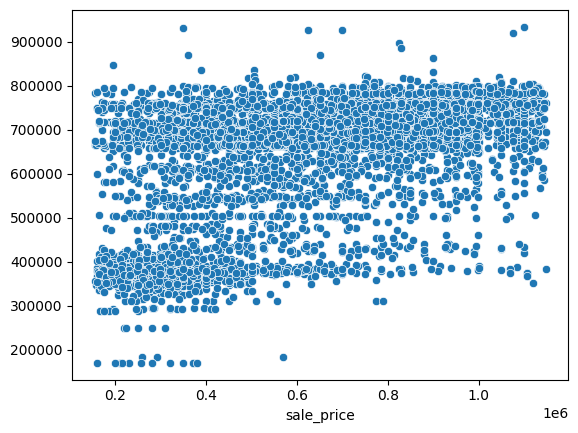

In [39]:
# If these values follow a line = good predictions
sns.scatterplot(x=y_test, y=predictions)


In [40]:
df['predicted_price'] = lm.predict(X)

In [41]:
df["error margin"] = abs(df["sale_price"] - df['predicted_price'])
case_df = df[df['error margin'] > 300000].sort_values(by='error margin', ascending=False)
case_df

,sale_price,lotarea,bldgarea,unitsres,unitstotal,numfloors,building_age,borough_y_BK,borough_y_BX,borough_y_MN,...,bldgclass_K1,bldgclass_K2,bldgclass_K4,bldgclass_O2,bldgclass_S1,bldgclass_S2,bldgclass_S3,bldgclass_S9,predicted_price,error margin
4048,1120000,118122.0,332660.0,330.0,330.0,6.0,73.0,0,0,0,...,0,0,0,0,0,0,0,0,351210.412652,768789.587348
13872,1078000,313647.0,883265.0,1022.0,1026.0,15.0,75.0,1,0,0,...,0,0,0,0,0,0,0,0,309883.794351,768116.205649
23675,1148000,10000.0,52454.0,43.0,43.0,6.0,93.0,0,0,0,...,0,0,0,0,0,0,0,0,383273.934188,764726.065812
20898,1107284,84760.0,225240.0,207.0,208.0,6.0,60.0,0,0,0,...,0,0,0,0,0,0,0,0,367403.921574,739880.078426
20903,1107284,84760.0,225240.0,207.0,208.0,6.0,60.0,0,0,0,...,0,0,0,0,0,0,0,0,367403.921574,739880.078426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31028,1050000,4500.0,2166.0,2.0,2.0,2.0,55.0,0,0,0,...,0,0,0,0,0,0,0,0,749931.943868,300068.056132
9797,1025000,1622.0,3600.0,2.0,3.0,3.0,100.0,0,1,0,...,0,0,0,0,0,1,0,0,724978.508278,300021.491722
17981,998000,2000.0,1955.0,1.0,1.0,2.0,90.0,1,0,0,...,0,0,0,0,0,0,0,0,697979.249369,300020.750631
6721,362000,1575.0,1374.0,1.0,1.0,2.0,126.0,0,1,0,...,0,0,0,0,0,0,0,0,662011.414450,300011.414450


In [42]:
filter_df = case_df[case_df["landuse_3.0"] == 1]

# If these values follow a line = good predictions
sns.scatterplot(filter_df , x='sale_price', y='predicted_price')

KeyError: 'landuse_3.0'

---

#### Model Application

|Step|Description|
|---|---|
|1|Data Cleaning|
|2| Feature Engineering|
|3| ML Implementation|
|4|<bold style="background:yellow;color:black;"> Model Application</bold>|